In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

In [2]:
## Cleaned Data

eco_df = pd.read_csv('../datasets/eco_df_clean.csv')


In [3]:
## Raws that are related to Toxoplasmosis only

tox_keywords = [
    'toxoplasma',
    'toxoplasmosis',
    'toxoplasma gondii'
]

df_toxo_eco = eco_df[
    eco_df['Details']
    .str.lower()
    .str.contains('|'.join(tox_keywords), na=False)
]



## CATS only

cats_only_df = eco_df[
    eco_df['Common_name']
    .astype(str)
    .str.lower()
    .str.contains(r'\bcat\b', na=False) &
    ~eco_df['Common_name'].str.contains(r',|\+|/|;|\band\b', case=False, na=False)
]


## Subset with multispecies
multi_species_df_eco = eco_df[
    eco_df['Common_name']
    .str.lower()
    .str.contains('cat', na=False) &
    eco_df['Common_name']
    .str.contains(',|\+| and |;', na=False)
]


<>:34: SyntaxWarning: invalid escape sequence '\+'
<>:34: SyntaxWarning: invalid escape sequence '\+'
C:\Users\benedek\AppData\Local\Temp\ipykernel_16420\3130657380.py:34: SyntaxWarning: invalid escape sequence '\+'
  .str.contains(',|\+| and |;', na=False)


In [4]:
eco_df

,Species,Common_name,Environment,urbanArea,Island,Official_country,State|Province|Administrative_area,Location,Time_range,Probable_starting_year,Probable_ending_year,Cost_estimate_per_year_2017_USD_exchange_rate,Cost_estimate_per_year_2017_USD_PPP,Currency,Applicable_year,Impacted_sector,Type_of_cost,Type_of_cost_merged,Benefit_value(s),Details
0,Felis catus,Feral Cat,Terrestrial,other,Y,Australia,Unspecified,Diverse/Unspecified,Year,2000,Unspecified,8.252764e+05,1.085696e+06,AUD,2000,Authorities-Stakeholders,Control,Management,no,Governments are estimated to spend at least $1...
1,Felis catus,Feral Cat,Terrestrial,other,Y,Australia,Unspecified,Dirk Hartog Island\r\nArea (62 790 Ha),Year,Unspecified,Unspecified,1.210041e+07,8.661407e+06,USD,2013,Authorities-Stakeholders,Eradication,Management,no,Cost of eradication if no internal fence is bu...
2,Felis catus,Feral Cat,Terrestrial,other,Y,Australia,Unspecified,Dirk Hartog Island\r\nArea (62 790 Ha),Year,2013,2013,2.946186e+04,2.108864e+04,USD,2013,Authorities-Stakeholders,Control,Management,no,Add +20 000 $ for material at each boundary of...
3,Felis catus/Oryctolagus cuniculus/Vulpes vulpes,Cat/Red fox/Rabbit,Terrestrial,other,Y,Australia,Unspecified,Wardang Island/Currawinya National Park/Royal ...,Year,2004,2004,9.543870e+03,9.507598e+03,AUD,2004,Authorities-Stakeholders,Control,Management,no,Cost of the fence material. \r\nFox + Feral ca...
4,Felis catus/Oryctolagus cuniculus/Vulpes vulpes,Cat/Red fox/Rabbit,Terrestrial,other,Y,Australia,Unspecified,Little Desert Lodge and Malleefowl Sanctuary/S...,Year,2004,2004,8.971238e+03,8.937142e+03,AUD,2004,Authorities-Stakeholders,Control,Management,no,Cost of the fence material. \r\nFox + Feral ca...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Diverse/Unspecified,"rabbits, hares, cats",Terrestrial,other,Y,Australia,South Australia,Yorke Peninsula coastal,Year,2011,2011,5.694082e+03,5.282024e+03,AUD,2016,Environment,Control,Management,no,Case Study 3: Yorke Peninsula Coastal
72,Diverse/Unspecified,"rabbits, hares, cats",Terrestrial,other,Y,Australia,South Australia,Yorke Peninsula coastal,Year,2012,2012,5.694082e+03,5.282024e+03,AUD,2016,Environment,Control,Management,no,Case Study 3: Yorke Peninsula Coastal
73,Diverse/Unspecified,"rabbits, hares, cats",Terrestrial,other,Y,Australia,South Australia,Yorke Peninsula coastal,Year,2013,2013,5.694082e+03,5.282024e+03,AUD,2016,Environment,Control,Management,no,Case Study 3: Yorke Peninsula Coastal
74,Diverse/Unspecified,"rabbits, hares, cats",Terrestrial,other,Y,Australia,South Australia,Yorke Peninsula coastal,Year,2014,2014,3.416449e+03,3.169214e+03,AUD,2016,Environment,Control,Management,no,Case Study 3: Yorke Peninsula Coastal


## Cats VS. Cats and someone else

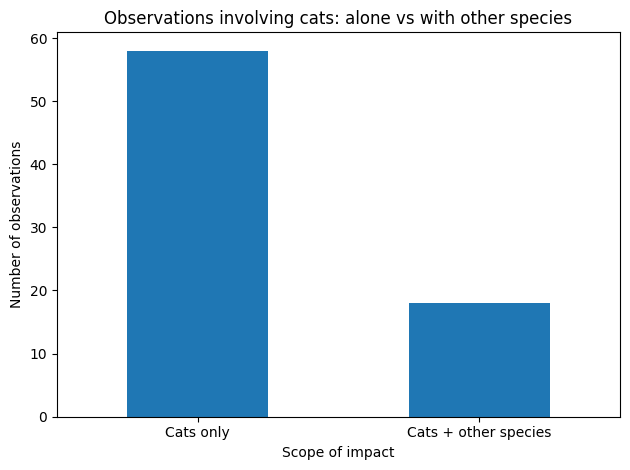

In [6]:
##  Create scope variable
eco_df['cat_scope'] = eco_df['Common_name'].apply(
    lambda x: 'Cats only'
    if isinstance(x, str) and ',' not in x
    else 'Cats + other species'
)

## Count observations
cat_counts = eco_df['cat_scope'].value_counts()

## Plot
plt.figure()
cat_counts.plot(kind='bar')
plt.title('Observations involving cats: alone vs with other species')
plt.xlabel('Scope of impact')
plt.ylabel('Number of observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Types of Cost

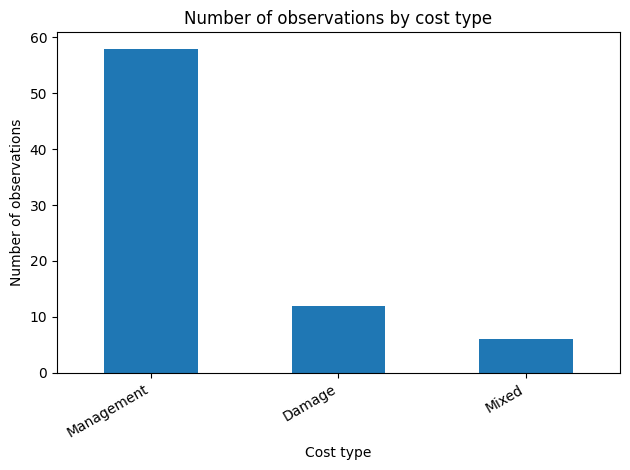

In [7]:
type_counts = eco_df['Type_of_cost_merged'].value_counts()

plt.figure()
type_counts.plot(kind='bar')
plt.title('Number of observations by cost type')
plt.xlabel('Cost type')
plt.ylabel('Number of observations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Cost Type: Cats VS. Cats + others...